In [1]:
import illustris_python as il
import numpy as np
from scipy.stats import binned_statistic_2d
import matplotlib.pyplot as plt
import numpy as np

In [2]:
basePath = '../sims.TNG/TNG50-3/output/'

In [3]:
header = il.groupcat.loadHeader(basePath, 99)
nPixels = [600,600]
minMax = [0, header['BoxSize']]
grid = np.zeros((nPixels[0], nPixels[1]))
nFiles = header['NumFiles']

In [4]:
import h5py
import os

grid = np.zeros((nPixels[0], nPixels[1]))

snapPath = os.path.join(basePath, 'snapdir_099')
snapFiles = sorted([f for f in os.listdir(snapPath) if f.endswith('.hdf5')])
nFiles = len(snapFiles)

for i, fname in enumerate(snapFiles):
    fpath = os.path.join(snapPath, fname)
    with h5py.File(fpath, 'r') as f:
        if 'PartType0' not in f:
            continue
        coords = f['PartType0/Coordinates'][:]
        masses = f['PartType0/Masses'][:]

    x = coords[:, 0]
    y = coords[:, 1]

    g, _, _, _ = binned_statistic_2d(x, y, masses, 'sum',
                                     bins=nPixels,
                                     range=[minMax, minMax])
    grid += g
    del coords, masses, x, y, g
    print(f'Arquivo {i+1}/{nFiles} processado')

Arquivo 1/11 processado
Arquivo 2/11 processado
Arquivo 3/11 processado
Arquivo 4/11 processado
Arquivo 5/11 processado
Arquivo 6/11 processado
Arquivo 7/11 processado
Arquivo 8/11 processado
Arquivo 9/11 processado
Arquivo 10/11 processado
Arquivo 11/11 processado


In [5]:
'''for i in range(nFiles):
    chunk = il.snapshot.loadSubfile(basePath, 99, 'gas', i,
                                    fields=['Masses', 'Coordinates'])
    if chunk['count'] == 0:
        continue

    x = chunk['Coordinates'][:, 0]
    y = chunk['Coordinates'][:, 1]
    w = chunk['Masses']

    g, _, _, _ = binned_statistic_2d(x, y, w, 'sum',
                                     bins=nPixels,
                                     range=[minMax, minMax])
    grid += g
    del chunk, x, y, w, g
    print(f'Arquivo {i+1}/{nFiles} processado')'''

"for i in range(nFiles):\n    chunk = il.snapshot.loadSubfile(basePath, 99, 'gas', i,\n                                    fields=['Masses', 'Coordinates'])\n    if chunk['count'] == 0:\n        continue\n\n    x = chunk['Coordinates'][:, 0]\n    y = chunk['Coordinates'][:, 1]\n    w = chunk['Masses']\n\n    g, _, _, _ = binned_statistic_2d(x, y, w, 'sum',\n                                     bins=nPixels,\n                                     range=[minMax, minMax])\n    grid += g\n    del chunk, x, y, w, g\n    print(f'Arquivo {i+1}/{nFiles} processado')"

In [6]:
#gas = il.snapshot.loadSubset(basePath, 99, 'gas', fields=['Masses','Coordinates'])

In [7]:
'''x = gas['Coordinates'][:,0]
y = gas['Coordinates'][:,1]
weights = gas['Masses']
nPixels = [300,300]
minMax = [0, header['BoxSize']]

grid, _, _, _ = binned_statistic_2d(x, y, weights, 'sum', bins=nPixels, range=[minMax,minMax])'''

"x = gas['Coordinates'][:,0]\ny = gas['Coordinates'][:,1]\nweights = gas['Masses']\nnPixels = [300,300]\nminMax = [0, header['BoxSize']]\n\ngrid, _, _, _ = binned_statistic_2d(x, y, weights, 'sum', bins=nPixels, range=[minMax,minMax])"

In [8]:
pxSize = header['BoxSize'] / nPixels[0]
pxSize_kpc = pxSize * header['Time'] / header['HubbleParam']
pxArea = pxSize_kpc**2

grid_log_msun_per_kpc2 = np.log10(grid * 1e10 / header['HubbleParam'] / pxArea)

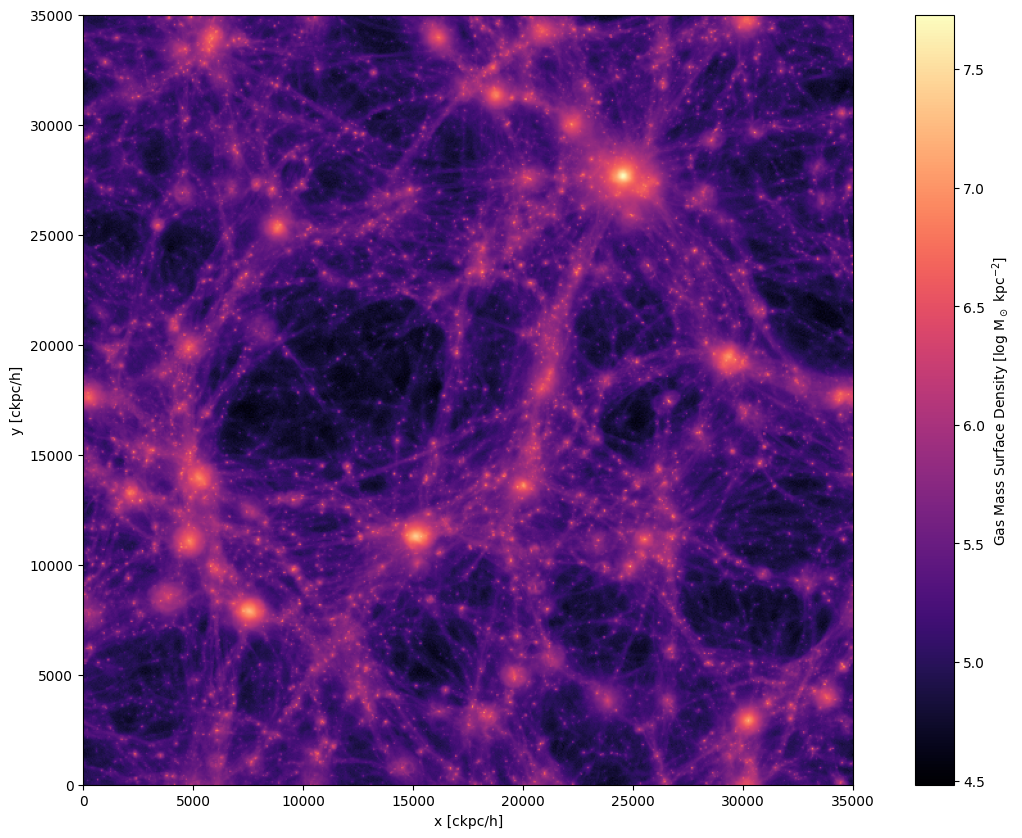

In [9]:
fig = plt.figure(figsize=(16,10))
ax = fig.add_subplot(111)

extent = [0, header['BoxSize'], 0, header['BoxSize']]
plt.imshow(grid_log_msun_per_kpc2, extent=extent, cmap='magma', aspect=nPixels[1]/nPixels[0])
ax.autoscale(False)
ax.set_xlabel('x [ckpc/h]')
ax.set_ylabel('y [ckpc/h]')
plt.colorbar(label='Gas Mass Surface Density [log M$_\odot$ kpc$^{-2}$]');
plt.savefig('v2_Gas_Mass_Surface_Density_tng50.png', dpi=150)